In [6]:
# LOAD LIBRARIES.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

### Newton Solver

Main questions:
- How does the number of Newton iterations scale as $N$ increases?
- How does the number of CG iterations scale as $N$ increases?
- Is $dt = \mathcal{O}(1/N)$ good enough?

In [7]:
beta = 2.0; T = 4.0; M = 50; potential_name = "quartic";
N_range = [30, 50, 100, 150, 200, 250]
results = {}

for j, N in enumerate(N_range):
    clear_output(wait = True)
    print(f"Running N = {N}.")

    dt = 1/(2*N); total_steps = int(T/dt);
    init = random_matrix.init_gue_eigenvalues(M, N)

    maimla_pipe = simulate.make_imla_pipeline(N, dt, potential_name, beta, metropolise = True)
    trajectory = simulate.simulate_dbm(init, total_steps, maimla_pipe)

    config = {
        "track_snapshots": False,
        "track_accepts": True,
        "track_newton_info": True
    }

    info = simulate.analyse_trajectory(trajectory, total_steps, **config)
    results[(N, dt)] = info


Running N = 250.


In [8]:
mean_newton_iters = np.zeros_like(N_range, dtype = float) 
mean_cg_iters = np.zeros_like(N_range, dtype = float)
mean_line_search_rejects = np.zeros_like(N_range, dtype = float)
mean_acc_rate = np.zeros_like(N_range, dtype = float)


for j, N in enumerate(N_range):
    dt = 1/(2*N)
    info = results[(N, dt)]
    mean_newton_iters[j] = info["newton_iters"].mean()
    mean_cg_iters[j] = info["mean_cg_iters"].mean()
    mean_line_search_rejects[j] = info["line_search_rejects"].mean()
    mean_acc_rate[j] = info["accepts"].mean()

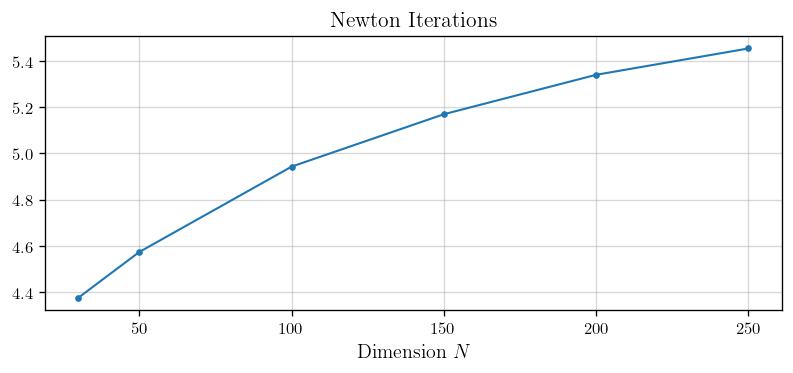

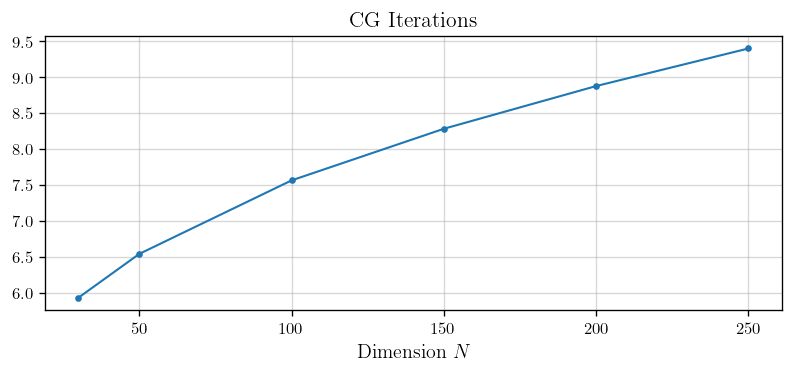

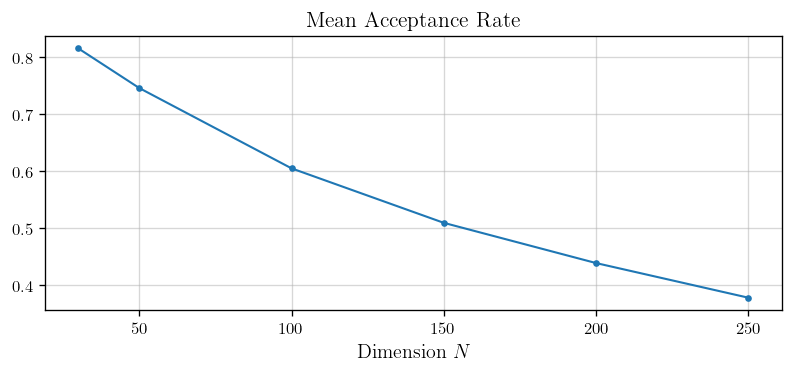

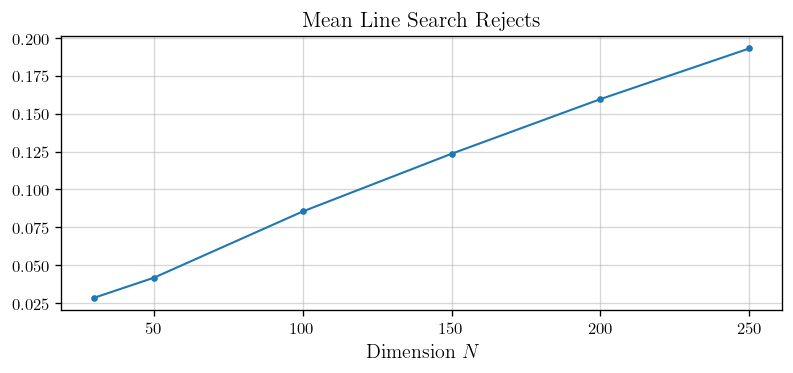

In [9]:
ax_titles = ["Newton Iterations", "CG Iterations", "Mean Acceptance Rate", "Mean Line Search Rejects"]
for title, arr in zip(ax_titles, [mean_newton_iters, mean_cg_iters, mean_acc_rate, mean_line_search_rejects]):
    fig, ax = plt.subplots()
    ax.plot(N_range, arr, marker = 'o', markersize = 3)
    ax.set_title(title)
    ax.set_xlabel(r"Dimension $N$"); 

    plt.show()